# Entrega 2 — Perfilado, Diccionario y Limpieza Inicial
**Curso:** Data Visualization  
**Carrera:** Ciencias de la Computación — UPC  
**Alumnos:** Vilchez Marin, Rody Sebastian | Ballon Villar, Diego Eduardo | Velasquez Borasino, Christian Aaron  
**Dataset:** Danish Residential Housing Prices 1992–2024  
**Unidad de análisis:** Transacción individual de compraventa de propiedad residencial en Dinamarca

## 0. Dependencias

In [1]:
!pip install mlcroissant

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 2.8 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.1 MB 2.6 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 2.8 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 2.9 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 1.8 MB/s  0:00:01
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.8 MB 3.4 MB/s eta 0:00:03
   

In [2]:
import mlcroissant as mlc
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Carga del dataset vía Croissant (Kaggle)

In [3]:
import mlcroissant as mlc
import pandas as pd

CROISSANT_URL = (
    "https://www.kaggle.com/datasets/"
    "martinfrederiksen/danish-residential-housing-prices-1992-2024"
    "/croissant/download"
)

print("⏳ Conectando con Kaggle via Croissant...")
dataset = mlc.Dataset(CROISSANT_URL)

# --- LÓGICA PARA BUSCAR EL DATASET COMPLETO ---
# Listamos todos los record sets disponibles para encontrar el que NO es sample
record_sets = dataset.metadata.record_sets
full_rs_name = None

if not record_sets:
    print("⚠️ No se encontraron record sets en la metadata del dataset. No se puede cargar ningún dato.")
else:
    for rs in record_sets:
        print(f"🔍 Encontrado set: {rs.name}")
        # Buscamos el set que NO diga 'Sample' o que sea el archivo principal
        if "Sample" not in rs.name:
            full_rs_name = rs.name
            break # Found a non-sample, break the loop

    # Si no encontró uno sin la palabra 'Sample', por defecto intentamos con el primer índice.
    # Nota: Si el CROISSANT_URL solo contiene el dataset de muestra, se cargará el de muestra.
    if not full_rs_name:
        if len(record_sets) > 0:
            full_rs_name = record_sets[0].name
            print(f"⚠️ No se encontró un record set sin 'Sample' en el nombre. Seleccionando el primero disponible: {full_rs_name} (posiblemente la muestra)")
        else:
            print("⚠️ No hay record sets disponibles para seleccionar.")

if full_rs_name:
    print(f"🚀 Seleccionado para descarga: {full_rs_name}")

    print("⏳ Descargando datos (esto puede tardar más)...")
    records = dataset.records(record_set=full_rs_name)

    # Convertimos a DataFrame
    df_raw = pd.DataFrame(list(records))

    # Limpiar prefijos de columnas
    df_raw.columns = [c.split('/')[-1] for c in df_raw.columns]

    print(f"✅ Descarga completa: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
    df_raw.head(3)
else:
    print("❌ No se pudo determinar qué record set descargar. No se cargaron datos.")
    df_raw = pd.DataFrame() # Ensure df_raw is defined even if no data is loaded


⏳ Conectando con Kaggle via Croissant...


  -  [Metadata(Danish Residential Housing Prices 1992-2024)] Property "http://mlcommons.org/croissant/citeAs" is recommended, but does not exist.


🔍 Encontrado set: DKHousingPricesSample100k.csv
⚠️ No se encontró un record set sin 'Sample' en el nombre. Seleccionando el primero disponible: DKHousingPricesSample100k.csv (posiblemente la muestra)
🚀 Seleccionado para descarga: DKHousingPricesSample100k.csv
⏳ Descargando datos (esto puede tardar más)...


✅ Descarga completa: 100,000 filas × 19 columnas


In [4]:
df_raw.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%25_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%25,dk_ann_infl_rate%25,yield_on_mortgage_credit_bonds%25
0,2024-10-24,b'2024Q4',b'16',b'Villa',b'regular_sale',1997,6500000,-3.0000,5,142.0000,45774.6500,b'Sp\xc3\xa6ttevej 16',2680,b'Solr\xc3\xb8d Strand',"b'Capital, Copenhagen'",b'Zealand',3.1000,NaN,NaN
1,2024-10-24,b'2024Q4',b'13',b'Apartment',b'regular_sale',1885,3400000,0.0000,2,46.0000,73913.0500,"b'Jakob Dannef\xc3\xa6rds Vej 10B, 4. th'",1973,b'Frederiksberg C',"b'Capital, Copenhagen'",b'Zealand',3.1000,NaN,NaN
2,2024-10-23,b'2024Q4',b'60',b'Villa',b'regular_sale',1949,4550000,-4.0000,4,112.0000,40625.0000,b'Vestre Plantagevej 3',2680,b'Solr\xc3\xb8d Strand',"b'Capital, Copenhagen'",b'Zealand',3.1000,NaN,NaN
3,2024-10-23,b'2024Q4',b'29',b'Villa',b'regular_sale',2001,1630000,-12.0000,4,186.0000,8763.4400,b'Toftebjerg 3',4400,b'Kalundborg',b'Other islands',b'Zealand',3.1000,NaN,NaN
4,2024-10-22,b'2024Q4',b'92',b'Apartment',b'regular_sale',1965,1975000,-10.0000,3,82.0000,24085.3650,"b'Rytterg\xc3\xa5rdsvej 20, 1. 113'",3520,b'Farum',b'North Zealand',b'Zealand',3.1000,NaN,NaN


## 2. Perfilado completo del dataset
### 2.1 Vista general — tipos y nulos

In [5]:
print("=" * 60)
print(f"Filas:    {df_raw.shape[0]:>12,}")
print(f"Columnas: {df_raw.shape[1]:>12}")
print(f"Memoria:  {df_raw.memory_usage(deep=True).sum() / 1e6:>11.1f} MB")
print("=" * 60)
df_raw.info()

Filas:         100,000
Columnas:           19
Memoria:         49.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                                 Non-Null Count   Dtype         
---  ------                                 --------------   -----         
 0   date                                   100000 non-null  datetime64[us]
 1   quarter                                100000 non-null  object        
 2   house_id                               100000 non-null  object        
 3   house_type                             100000 non-null  object        
 4   sales_type                             100000 non-null  object        
 5   year_build                             100000 non-null  int64         
 6   purchase_price                         100000 non-null  int64         
 7   %25_change_between_offer_and_purchase  100000 non-null  float64       
 8   no_rooms                               100000 non-null  int64    

### 2.2 Tabla de perfilado por columna

In [6]:
def perfilar(df):
    rows = []
    n = len(df)
    for col in df.columns:
        s = df[col]
        nulos = s.isna().sum()
        card  = s.nunique(dropna=True)
        dtype = str(s.dtype)
        es_num = pd.api.types.is_numeric_dtype(s)
        row = {
            'columna':        col,
            'dtype_raw':      dtype,
            'nulos':          nulos,
            'pct_nulo':       round(nulos / n * 100, 3),
            'cardinalidad':   card,
            'pct_card':       round(card / n * 100, 4),
            'min':            s.min() if es_num else s.dropna().min() if card > 0 else None,
            'max':            s.max() if es_num else s.dropna().max() if card > 0 else None,
            'media':          round(s.mean(), 4) if es_num else None,
            'mediana':        s.median() if es_num else None,
            'std':            round(s.std(), 4) if es_num else None,
            'valores_muestra': str(s.dropna().unique()[:5].tolist()),
        }
        rows.append(row)
    return pd.DataFrame(rows)

perfil = perfilar(df_raw)
perfil

,columna,dtype_raw,nulos,pct_nulo,cardinalidad,pct_card,min,max,media,mediana,std,valores_muestra
0,date,datetime64[us],0,0.0000,11254,11.2540,1992-01-05 00:00:00,2024-10-24 00:00:00,NaN,NaN,NaN,"[Timestamp('2024-10-24 00:00:00'), Timestamp('..."
1,quarter,object,0,0.0000,130,0.1300,b'1992Q1',b'2024Q4',NaN,NaN,NaN,"[b'2024Q4', b'2024Q3', b'2024Q2', b'2024Q1', b..."
2,house_id,object,0,0.0000,100000,100.0000,b'100',b'999986',NaN,NaN,NaN,"[b'16', b'13', b'60', b'29', b'92']"
3,house_type,object,0,0.0000,5,0.0050,b'Apartment',b'Villa',NaN,NaN,NaN,"[b'Villa', b'Apartment', b'Summerhouse', b'Tow..."
4,sales_type,object,0,0.0000,4,0.0040,b'auction',b'regular_sale',NaN,NaN,NaN,"[b'regular_sale', b'family_sale', b'other_sale..."
5,year_build,int64,0,0.0000,344,0.3440,1000,2024,1955.0785,1966.0000,45.7036,"[1997, 1885, 1949, 2001, 1965]"
6,purchase_price,int64,0,0.0000,14100,14.1000,250200,45955000,1925992.2005,1400000.0000,1777832.1983,"[6500000, 3400000, 4550000, 1630000, 1975000]"
7,%25_change_between_offer_and_purchase,float64,0,0.0000,97,0.0970,-49.0000,49.0000,-2.0847,0.0000,4.8529,"[-3.0, 0.0, -4.0, -12.0, -10.0]"
8,no_rooms,int64,0,0.0000,15,0.0150,1,15,4.3758,4.0000,1.6617,"[5, 2, 4, 3, 6]"
9,sqm,float64,0,0.0000,516,0.5160,26.0000,984.0000,129.3878,123.0000,57.1706,"[142.0, 46.0, 112.0, 186.0, 82.0]"


### 2.3 Duplicados

In [7]:
dup_total = df_raw.duplicated().sum()
dup_house = df_raw.duplicated(subset=['house_id']).sum()
dup_clave = df_raw.duplicated(subset=['house_id', 'date']).sum()

print(f"Filas duplicadas (todas las columnas):  {dup_total:,}")
print(f"house_id duplicados:                    {dup_house:,}")
print(f"Duplicados por (house_id, date):        {dup_clave:,}")

Filas duplicadas (todas las columnas):  0
house_id duplicados:                    0
Duplicados por (house_id, date):        0


### 2.4 Campos críticos — detalle de nulos

In [8]:
CRITICOS = ['date', 'house_id', 'purchase_price', 'house_type', 'sqm', 'region', 'area']
print("Nulos en campos críticos:")
print(df_raw[CRITICOS].isna().sum().to_frame('nulos'))

Nulos en campos críticos:
                nulos
date                0
house_id            0
purchase_price      0
house_type          0
sqm                 0
region              0
area                0


### 2.5 Distribución de variables categóricas clave

In [9]:
for col in ['house_type', 'sales_type', 'region', 'quarter']:
    if col in df_raw.columns:
        print(f"\n── {col} ──")
        vc = df_raw[col].value_counts(dropna=False)
        print(vc.to_frame('n').assign(pct=lambda x: (x['n'] / len(df_raw) * 100).round(2)))


── house_type ──
                    n     pct
house_type                   
b'Villa'        54214 54.2100
b'Apartment'    19354 19.3500
b'Summerhouse'  11344 11.3400
b'Townhouse'    10184 10.1800
b'Farm'          4904  4.9000

── sales_type ──
                     n     pct
sales_type                    
b'regular_sale'  88232 88.2300
b'family_sale'    8224  8.2200
b'other_sale'     2489  2.4900
b'auction'        1055  1.0600

── region ──
                      n     pct
region                         
b'Jutland'        49937 49.9400
b'Zealand'        39740 39.7400
b'Fyn & islands'   9264  9.2600
b'Bornholm'        1059  1.0600

── quarter ──
              n    pct
quarter               
b'2021Q1'  2263 2.2600
b'2021Q2'  2245 2.2400
b'2020Q4'  1942 1.9400
b'2020Q3'  1853 1.8500
b'2021Q3'  1740 1.7400
...         ...    ...
b'1992Q3'   290 0.2900
b'1994Q1'   284 0.2800
b'1993Q1'   241 0.2400
b'1992Q4'   230 0.2300
b'2024Q4'    77 0.0800

[130 rows x 2 columns]


### 2.6 Rango temporal y cobertura

In [10]:
df_raw['date'] = pd.to_datetime(df_raw['date'], errors='coerce')
print(f"Fecha mínima: {df_raw['date'].min()}")
print(f"Fecha máxima: {df_raw['date'].max()}")
print(f"Cobertura:    {(df_raw['date'].max() - df_raw['date'].min()).days / 365.25:.1f} años")

Fecha mínima: 1992-01-05 00:00:00
Fecha máxima: 2024-10-24 00:00:00
Cobertura:    32.8 años


### 2.7 Estadísticas descriptivas — variables numéricas

In [11]:
NUMS = ['purchase_price', 'sqm', 'sqm_price', 'no_rooms',
        'nom_interest_rate%25', 'dk_ann_infl_rate%25', 'yield_on_mortgage_credit_bonds%25']
NUMS_OK = [c for c in NUMS if c in df_raw.columns]
df_raw[NUMS_OK].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
purchase_price,100000.0000,1925992.2005,1777832.1983,250200.0000,287000.0000,392677.6500,800000.0000,1400000.0000,2450000.0000,5145250.0000,8600000.0000,45955000.0000
sqm,100000.0000,129.3878,57.1706,26.0000,40.0000,54.0000,89.0000,123.0000,160.0000,227.0000,304.0000,984.0000
sqm_price,100000.0000,16406.6481,13655.1844,374.5498,1905.9386,3073.7517,6792.9408,12070.7070,21343.2015,46250.0000,65245.8448,75000.0000
no_rooms,100000.0000,4.3758,1.6617,1.0000,1.0000,2.0000,3.0000,4.0000,5.0000,7.0000,9.0000,15.0000
nom_interest_rate%25,100000.0000,1.6793,2.0481,0.0000,0.0000,0.0000,0.0000,0.7500,3.2500,5.0000,9.5000,9.5000
dk_ann_infl_rate%25,99923.0000,1.9270,1.6384,0.2500,0.2500,0.4200,0.7900,1.8500,2.3400,7.7000,7.7000,7.7000
yield_on_mortgage_credit_bonds%25,99923.0000,4.1074,2.1944,1.1000,1.1000,1.1000,2.1200,4.3400,5.5000,8.1600,10.1400,10.1400


### 2.8 Identificación de outliers en precios (IQR)

In [12]:
for col in ['purchase_price', 'sqm', 'sqm_price']:
    if col not in df_raw.columns:
        continue
    Q1, Q3 = df_raw[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    n_out = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    pct = n_out / len(df_raw) * 100
    print(f"{col}: {n_out:,} outliers ({pct:.3f}%)  |  límite inferior={lower:,.0f}  superior={upper:,.0f}")

purchase_price: 1,668 outliers (1.668%)  |  límite inferior=-4,150,000  superior=7,400,000
sqm: 320 outliers (0.320%)  |  límite inferior=-124  superior=373
sqm_price: 1,038 outliers (1.038%)  |  límite inferior=-36,858  superior=64,994


---
## 3. Problemas de calidad identificados

| # | Problema | Columnas afectadas | Impacto | Regla de limpieza |
|---|----------|--------------------|---------|-------------------|
| P1 | Nulos en `city` (~11 registros) | `city` | Bajo | Imputar con `'Unknown'` |
| P2 | Nulos en `dk_ann_infl_rate%25` y `yield_on_mortgage_credit_bonds%25` (~77 cada uno, período 2023–2024) | Macro vars | Medio | Marcar con flag `macro_nulo=True`; no imputar |
| P3 | `sales_type = '-'` (~0.5%) — tipo no clasificable | `sales_type` | Medio | Excluir del análisis de precios; mantener en vistas de volumen |
| P4 | `year_build` con valores históricos extremos (< 1800) | `year_build` | Bajo | Filtrar `year_build < 1800` como `year_build_flag=True` |
| P5 | `purchase_price` con outliers extremos (IQR ×3) | `purchase_price`, `sqm_price` | Alto | Marcar con `precio_outlier=True`; excluir en análisis de tendencias |
| P6 | Registros 1992–1994 con menor completitud (`sqm`, `year_build`) | General | Alto | Marcar con `periodo_preliminar=True`; advertencia en tooltips |
| P7 | `zip_code` como int64 — debe ser string (ceros a la izquierda) | `zip_code` | Medio | Convertir a string con 4 dígitos (`zfill(4)`) para join con shapefile |
| P8 | Columnas de tasas nombradas con `%25` (encoding de `%`) | Macro vars | Bajo | Renombrar a nombres limpios sin `%25` |

---
## 4. Limpieza — aplicación de reglas

In [13]:
df = df_raw.copy()

# ── Bitácora de transformaciones ──────────────────────────────────────────────
bitacora = []  # cada entrada: dict con claves estandarizadas

def registrar(problema, columna, tipo, accion, n_afectados, dato_orig, dato_trans):
    bitacora.append({
        'problema_id': problema,
        'columna': columna,
        'tipo_problema': tipo,
        'accion': accion,
        'n_afectados': n_afectados,
        'dato_original': dato_orig,
        'dato_transformado': dato_trans,
    })

In [14]:
# ── P1: Nulos en city ─────────────────────────────────────────────────────────
n_city = df['city'].isna().sum()
df['city'] = df['city'].fillna('Unknown')
registrar('P1', 'city', 'Nulos', 'Imputar con Unknown',
          n_city, 'NaN', 'Unknown')
print(f"P1 ✓  city: {n_city} nulos imputados con 'Unknown'")

P1 ✓  city: 11 nulos imputados con 'Unknown'


In [15]:
# ── P2: Nulos en variables macro (no imputar) ─────────────────────────────────
macro_cols_raw = [c for c in df.columns if 'infl' in c or 'yield' in c]
n_macro = df[macro_cols_raw].isna().any(axis=1).sum()
df['macro_nulo'] = df[macro_cols_raw].isna().any(axis=1)
registrar('P2', str(macro_cols_raw), 'Nulos (macro, período 2023–2024)',
          'Crear flag macro_nulo=True; no imputar',
          n_macro, 'NaN', 'Flag macro_nulo=True')
print(f"P2 ✓  macro_nulo flag creado para {n_macro:,} filas")

P2 ✓  macro_nulo flag creado para 77 filas


In [16]:
# ── P3: sales_type = '-' ──────────────────────────────────────────────────────
if 'sales_type' in df.columns:
    n_dash = (df['sales_type'] == '-').sum()
    df['sales_type_valido'] = df['sales_type'] != '-'
    registrar('P3', 'sales_type', 'Valor no clasificable',
              'Marcar sales_type_valido=False; excluir en análisis de precios',
              n_dash, "'-'", 'sales_type_valido=False')
    print(f"P3 ✓  {n_dash:,} filas con sales_type='-' marcadas")

P3 ✓  0 filas con sales_type='-' marcadas


In [17]:
# ── P4: year_build < 1800 ─────────────────────────────────────────────────────
if 'year_build' in df.columns:
    df['year_build'] = pd.to_numeric(df['year_build'], errors='coerce')
    n_yb = (df['year_build'] < 1800).sum()
    df['year_build_flag'] = df['year_build'] < 1800
    registrar('P4', 'year_build', 'Valor atípico extremo',
              'Marcar year_build_flag=True para year_build < 1800',
              n_yb, 'year_build < 1800', 'year_build_flag=True')
    print(f"P4 ✓  {n_yb:,} registros con year_build < 1800 marcados")

P4 ✓  778 registros con year_build < 1800 marcados


In [18]:
# ── P5: Outliers en purchase_price y sqm_price (IQR ×3) ───────────────────────
for col in ['purchase_price', 'sqm_price']:
    if col not in df.columns:
        continue
    df[col] = pd.to_numeric(df[col], errors='coerce')
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    n_out = mask.sum()
    df[f'{col}_outlier'] = mask
    registrar('P5', col, 'Outlier extremo (IQR ×3)',
              f'Marcar {col}_outlier=True; excluir en análisis de tendencias',
              n_out, f'valor < {lower:,.0f} o > {upper:,.0f}', f'{col}_outlier=True')
    print(f"P5 ✓  {col}: {n_out:,} outliers marcados")

P5 ✓  purchase_price: 1,668 outliers marcados
P5 ✓  sqm_price: 1,038 outliers marcados


In [19]:
# ── P6: Período preliminar 1992–1994 ─────────────────────────────────────────
if 'date' in df.columns:
    n_prelim = (df['date'].dt.year < 1995).sum()
    df['periodo_preliminar'] = df['date'].dt.year < 1995
    registrar('P6', 'date / sqm / year_build', 'Menor completitud histórica',
              'Marcar periodo_preliminar=True para registros < 1995',
              n_prelim, 'año < 1995', 'periodo_preliminar=True')
    print(f"P6 ✓  {n_prelim:,} registros 1992–1994 marcados como período preliminar")

P6 ✓  3,696 registros 1992–1994 marcados como período preliminar


In [20]:
# ── P7: zip_code a string de 4 dígitos ───────────────────────────────────────
if 'zip_code' in df.columns:
    orig_dtype = str(df['zip_code'].dtype)
    df['zip_code'] = df['zip_code'].astype('Int64').astype(str).str.zfill(4)
    df['zip_code'] = df['zip_code'].replace('<NA>', pd.NA)
    registrar('P7', 'zip_code', 'Tipo incorrecto (int → string)',
              'Convertir a string de 4 dígitos con zfill(4)',
              len(df), f'int64 (ej: 1000)', 'string "1000"')
    print(f"P7 ✓  zip_code convertido de {orig_dtype} a string 4 dígitos")

P7 ✓  zip_code convertido de int64 a string 4 dígitos


In [21]:
# ── P8: Renombrar columnas con %25 ────────────────────────────────────────────
rename_map = {
    c: c.replace('%25', '_pct')
    for c in df.columns if '%25' in c
}
df.rename(columns=rename_map, inplace=True)
if rename_map:
    registrar('P8', str(list(rename_map.keys())), 'Nombre de columna con encoding URL',
              'Renombrar reemplazando %25 por _pct',
              len(rename_map), 'nom_interest_rate%25', 'nom_interest_rate_pct')
    print(f"P8 ✓  {len(rename_map)} columnas renombradas: {rename_map}")

P8 ✓  4 columnas renombradas: {'%25_change_between_offer_and_purchase': '_pct_change_between_offer_and_purchase', 'nom_interest_rate%25': 'nom_interest_rate_pct', 'dk_ann_infl_rate%25': 'dk_ann_infl_rate_pct', 'yield_on_mortgage_credit_bonds%25': 'yield_on_mortgage_credit_bonds_pct'}


### 4.1 Forzar tipos para compatibilidad con Tableau

In [22]:
# Tipos explícitos → sin ambigüedad en Tableau
type_map = {
    'date':            'datetime64[ns]',
    'house_id':        'string',
    'house_type':      'string',
    'sales_type':      'string',
    'quarter':         'string',
    'address':         'string',
    'city':            'string',
    'area':            'string',
    'region':          'string',
    'zip_code':        'string',
    'purchase_price':  'float64',
    'sqm':             'float64',
    'sqm_price':       'float64',
    'no_rooms':        'Int64',
    'year_build':      'Int64',
}
for col, dtype in type_map.items():
    if col in df.columns:
        try:
            df[col] = df[col].astype(dtype)
        except Exception as e:
            print(f"  ⚠ {col}: {e}")

print("✅ Tipos de datos aplicados")
print(df.dtypes)

✅ Tipos de datos aplicados
date                                      datetime64[ns]
quarter                                           string
house_id                                          string
house_type                                        string
sales_type                                        string
year_build                                         Int64
purchase_price                                   float64
_pct_change_between_offer_and_purchase           float64
no_rooms                                           Int64
sqm                                              float64
sqm_price                                        float64
address                                           string
zip_code                                          string
city                                              string
area                                              string
region                                            string
nom_interest_rate_pct                            float64
dk_a

---
## 5. Bitácora de transformaciones

In [23]:
df_bitacora = pd.DataFrame(bitacora)
df_bitacora

,problema_id,columna,tipo_problema,accion,n_afectados,dato_original,dato_transformado
0,P1,city,Nulos,Imputar con Unknown,11,NaN,Unknown
1,P2,"['dk_ann_infl_rate%25', 'yield_on_mortgage_cre...","Nulos (macro, período 2023–2024)",Crear flag macro_nulo=True; no imputar,77,NaN,Flag macro_nulo=True
2,P3,sales_type,Valor no clasificable,Marcar sales_type_valido=False; excluir en aná...,0,'-',sales_type_valido=False
3,P4,year_build,Valor atípico extremo,Marcar year_build_flag=True para year_build < ...,778,year_build < 1800,year_build_flag=True
4,P5,purchase_price,Outlier extremo (IQR ×3),Marcar purchase_price_outlier=True; excluir en...,1668,"valor < -4,150,000 o > 7,400,000",purchase_price_outlier=True
5,P5,sqm_price,Outlier extremo (IQR ×3),Marcar sqm_price_outlier=True; excluir en anál...,1038,"valor < -36,858 o > 64,994",sqm_price_outlier=True
6,P6,date / sqm / year_build,Menor completitud histórica,Marcar periodo_preliminar=True para registros ...,3696,año < 1995,periodo_preliminar=True
7,P7,zip_code,Tipo incorrecto (int → string),Convertir a string de 4 dígitos con zfill(4),100000,int64 (ej: 1000),"string ""1000"""
8,P8,"['%25_change_between_offer_and_purchase', 'nom...",Nombre de columna con encoding URL,Renombrar reemplazando %25 por _pct,4,nom_interest_rate%25,nom_interest_rate_pct


---
## 6. Dataset limpio preliminar
### 6.1 Resumen de flags creados

In [24]:
flags = [c for c in df.columns if c.endswith('_flag') or c.endswith('_outlier')
         or c in ('macro_nulo', 'periodo_preliminar', 'sales_type_valido')]

print("Flags de calidad — resumen:\n")
for f in flags:
    if df[f].dtype == bool or str(df[f].dtype) == 'boolean':
        n = df[f].sum()
        print(f"  {f:35s}: {n:>8,} ({n/len(df)*100:.2f}%)")

Flags de calidad — resumen:

  macro_nulo                         :       77 (0.08%)
  sales_type_valido                  :  100,000 (100.00%)
  year_build_flag                    :      778 (0.78%)
  purchase_price_outlier             :    1,668 (1.67%)
  sqm_price_outlier                  :    1,038 (1.04%)
  periodo_preliminar                 :    3,696 (3.70%)


In [25]:
# Vista de análisis principal: excluir casos problemáticos para análisis de precios
df_clean = df[
    df.get('sales_type_valido', True) &
    ~df.get('purchase_price_outlier', False) &
    ~df.get('periodo_preliminar', False)
].copy()

print(f"Dataset original:          {len(df):>10,} filas")
print(f"Dataset limpio (análisis): {len(df_clean):>10,} filas")
print(f"Filas excluidas:           {len(df) - len(df_clean):>10,} ({(1 - len(df_clean)/len(df))*100:.2f}%)")

Dataset original:             100,000 filas
Dataset limpio (análisis):     94,647 filas
Filas excluidas:                5,353 (5.35%)


### 6.2 Guardar archivos de salida

In [ ]:
# Dataset completo con flags (para Tableau — incluye todos los registros)
df.to_csv('dataset_limpio_con_flags.csv', index=False, encoding='utf-8-sig')

# Dataset filtrado para análisis de precios
df_clean.to_csv('dataset_limpio_analisis.csv', index=False, encoding='utf-8-sig')

# Bitácora
df_bitacora.to_csv('bitacora_transformaciones.csv', index=False, encoding='utf-8-sig')

# Tabla de perfilado
perfil.to_csv('tabla_perfilado.csv', index=False, encoding='utf-8-sig')

print("✅ Archivos guardados:")
print("   - dataset_limpio_con_flags.csv")
print("   - dataset_limpio_analisis.csv")
print("   - bitacora_transformaciones.csv")
print("   - tabla_perfilado.csv")

✅ Archivos guardados:
   - dataset_limpio_con_flags.csv
   - dataset_limpio_analisis.csv
   - bitacora_transformaciones.csv
   - tabla_perfilado.csv


---
## 8. Visualizaciones EDA
Todas las visualizaciones usan el dataset con flags aplicados (`df`). Los gráficos se organizan en 7 bloques temáticos que sustentan las decisiones de limpieza documentadas en la bitácora.

In [28]:
%pip install matplotlib seaborn

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl (7.1 MB)

   ---------------------------------------- 0/7 [pillow]
   ------

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Estilo global ─────────────────────────────────────────────────────────────
ROJO_UPC  = '#C0272D'
AZUL      = '#2E75B6'
GRIS      = '#4F4F4F'
PALETTE   = [ROJO_UPC, AZUL, '#E8A838', '#3DAA6D', '#7B5EA7', '#E06C3A']

plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   GRIS,
    'axes.labelsize':    10,
    'axes.labelcolor':   GRIS,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'font.family':       'DejaVu Sans',
})

def save_note(ax, text):
    ax.annotate(text, xy=(0, -0.18), xycoords='axes fraction',
                fontsize=8, color='#888888', style='italic')

### 8.1 Calidad por columna — nulos y cardinalidad

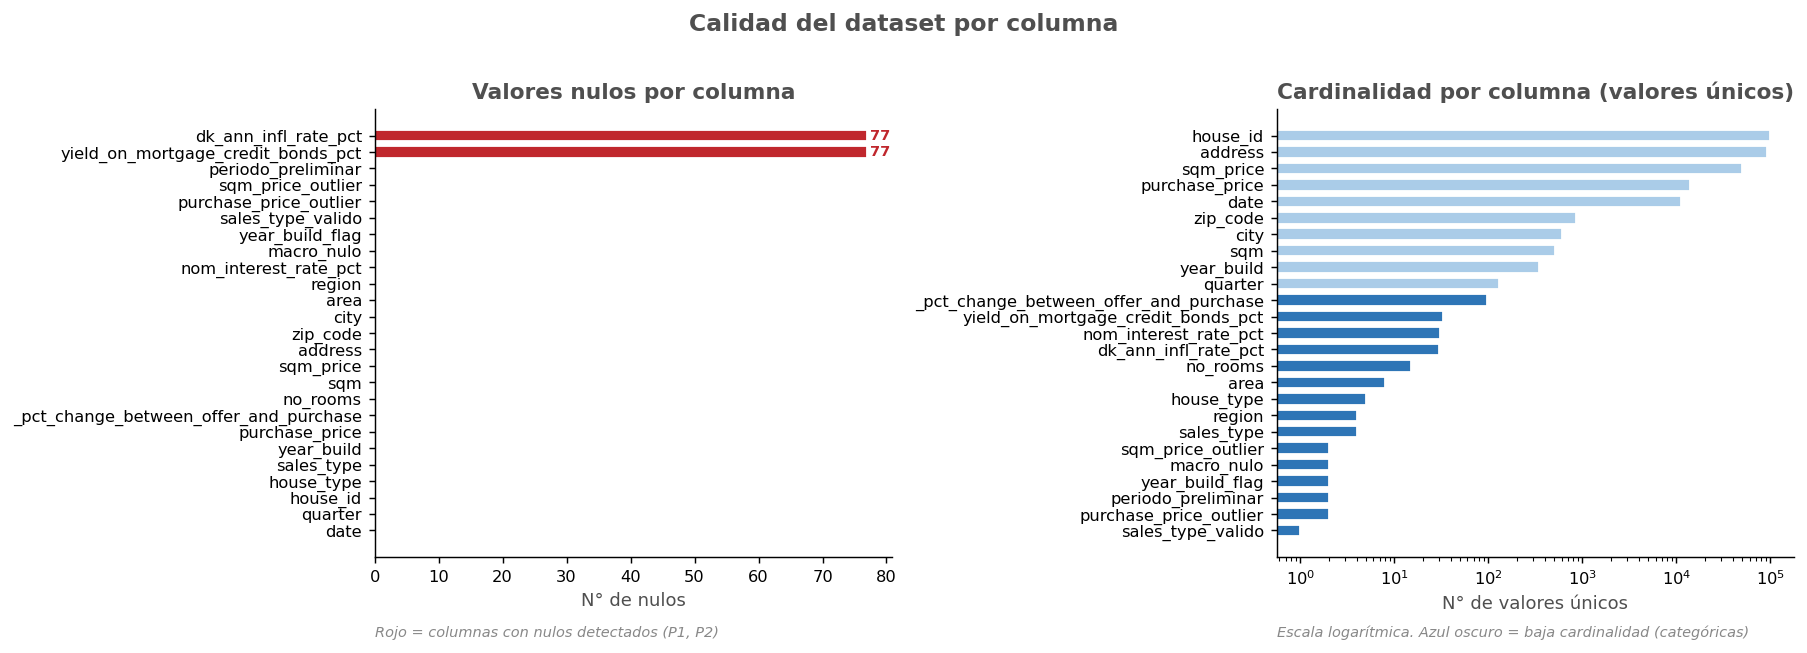

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Calidad del dataset por columna', fontsize=13, fontweight='bold', color=GRIS, y=1.01)

# Nulos
nulos_s = df.isna().sum().sort_values(ascending=True)
nulos_s = nulos_s[nulos_s >= 0]  # todas
colors_n = [ROJO_UPC if v > 0 else '#CCCCCC' for v in nulos_s.values]
axes[0].barh(nulos_s.index, nulos_s.values, color=colors_n, edgecolor='white', height=0.7)
axes[0].set_title('Valores nulos por columna')
axes[0].set_xlabel('N° de nulos')
for i, v in enumerate(nulos_s.values):
    if v > 0:
        axes[0].text(v + 0.5, i, str(v), va='center', fontsize=8, color=ROJO_UPC, fontweight='bold')
save_note(axes[0], 'Rojo = columnas con nulos detectados (P1, P2)')

# Cardinalidad
card_s = df.nunique().sort_values(ascending=True)
colors_c = [AZUL if v < 100 else '#AACCE8' for v in card_s.values]
axes[1].barh(card_s.index, card_s.values, color=colors_c, edgecolor='white', height=0.7)
axes[1].set_title('Cardinalidad por columna (valores únicos)')
axes[1].set_xlabel('N° de valores únicos')
axes[1].set_xscale('log')
save_note(axes[1], 'Escala logarítmica. Azul oscuro = baja cardinalidad (categóricas)')

plt.tight_layout()
plt.show()

### 8.2 Serie temporal — volumen de transacciones por año

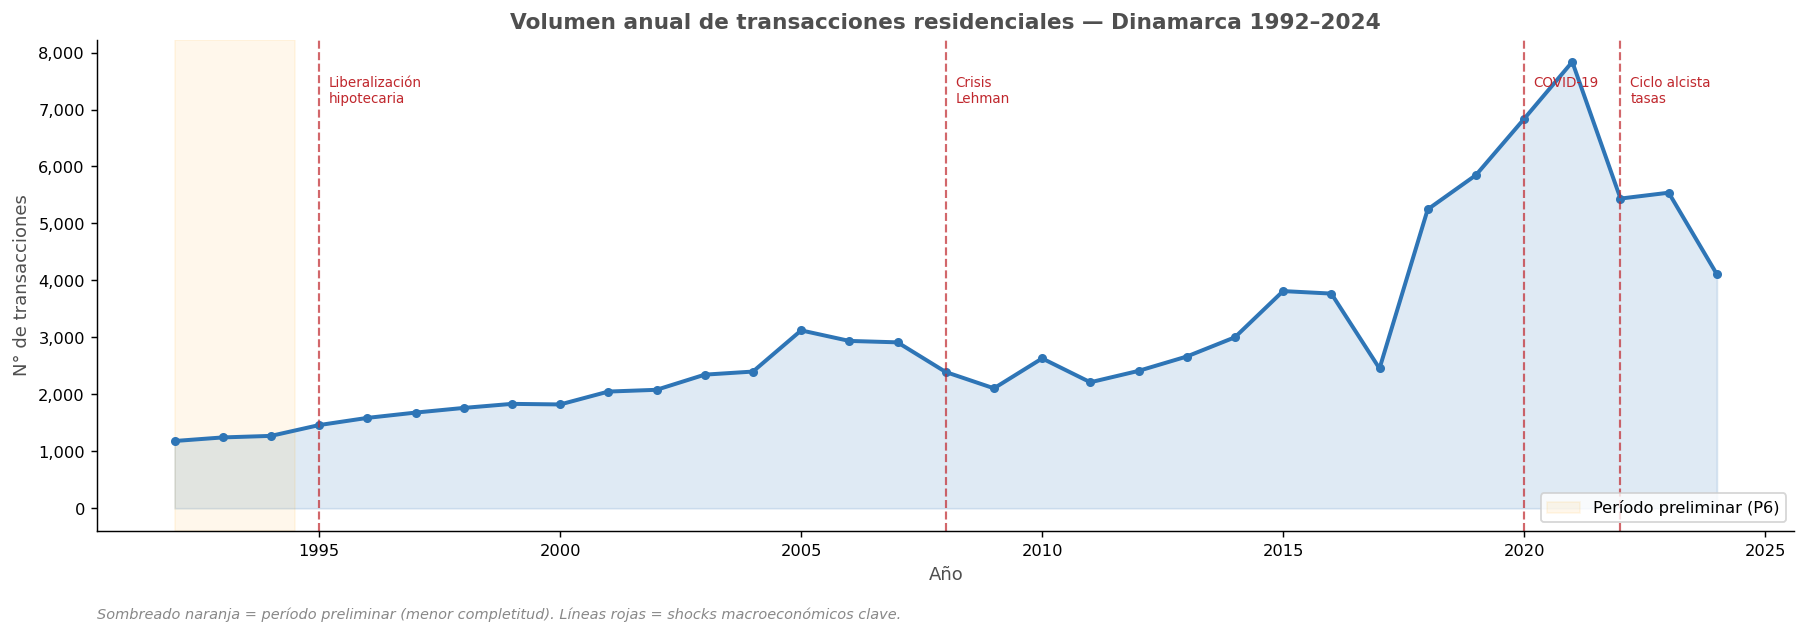

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))

ventas_anio = df.groupby(df['date'].dt.year).size().reset_index()
ventas_anio.columns = ['year', 'n']

ax.fill_between(ventas_anio['year'], ventas_anio['n'],
                alpha=0.15, color=AZUL)
ax.plot(ventas_anio['year'], ventas_anio['n'],
        color=AZUL, linewidth=2.2, marker='o', markersize=4)

# Marcadores de shocks macro
shocks = {1995: 'Liberalización\nhipotecaria', 2008: 'Crisis\nLehman', 2020: 'COVID-19', 2022: 'Ciclo alcista\ntasas'}
for yr, label in shocks.items():
    ax.axvline(yr, color=ROJO_UPC, linestyle='--', linewidth=1.2, alpha=0.7)
    ax.text(yr + 0.2, ventas_anio['n'].max() * 0.97, label,
            fontsize=7.5, color=ROJO_UPC, va='top')

# Período preliminar
ax.axvspan(1992, 1994.5, alpha=0.08, color='orange', label='Período preliminar (P6)')

ax.set_title('Volumen anual de transacciones residenciales — Dinamarca 1992–2024')
ax.set_xlabel('Año')
ax.set_ylabel('N° de transacciones')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='lower right')
save_note(ax, 'Sombreado naranja = período preliminar (menor completitud). Líneas rojas = shocks macroeconómicos clave.')

plt.tight_layout()
plt.show()

### 8.3 Distribución de precios — histograma y boxplot

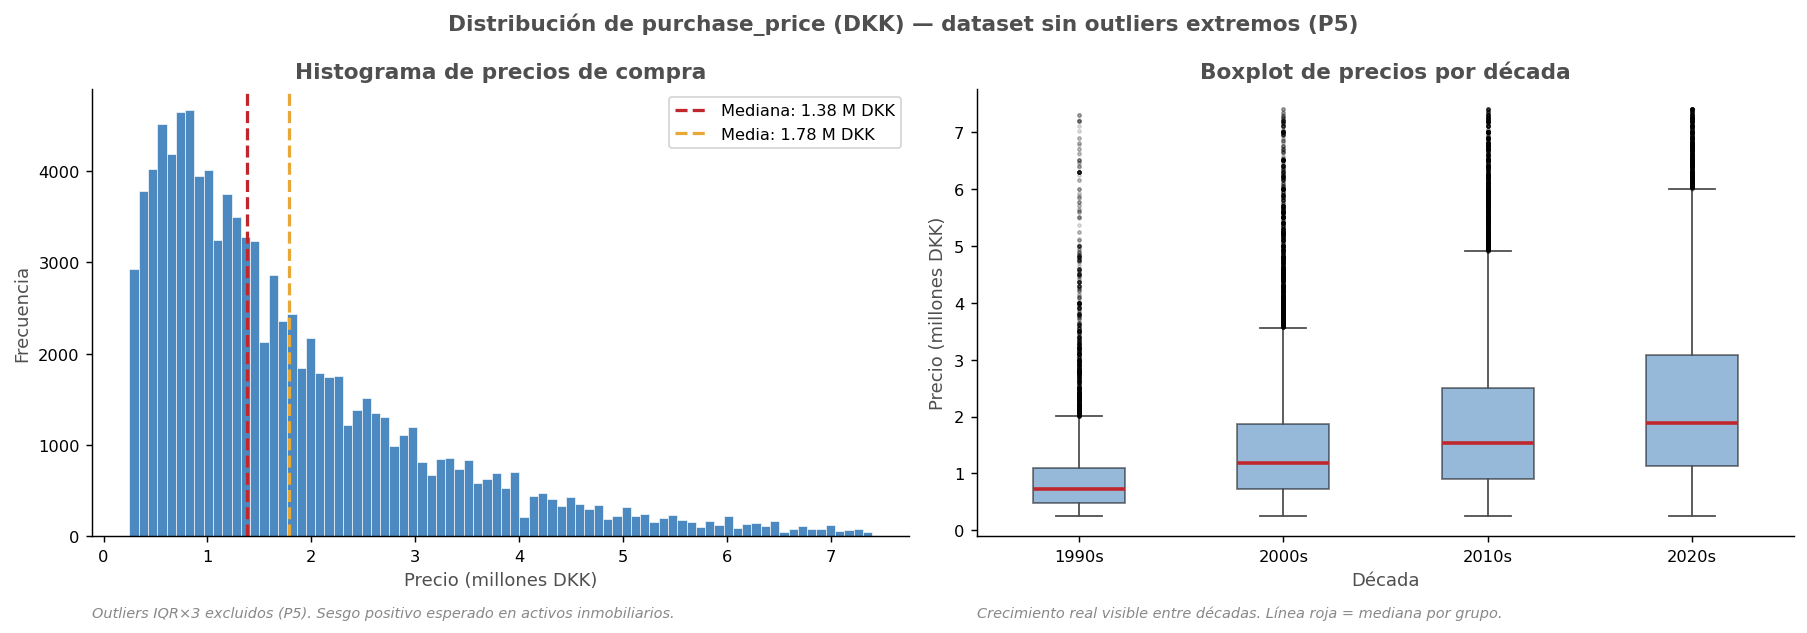

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de purchase_price (DKK) — dataset sin outliers extremos (P5)',
             fontsize=12, fontweight='bold', color=GRIS)

# Filtrar outliers para visualización limpia
col = 'purchase_price'
flag_col = 'purchase_price_outlier' if 'purchase_price_outlier' in df.columns else None
df_viz = df[~df[flag_col]].copy() if flag_col else df.copy()

# Histograma
axes[0].hist(df_viz[col].dropna() / 1e6, bins=80, color=AZUL,
             edgecolor='white', linewidth=0.4, alpha=0.85)
axes[0].axvline(df_viz[col].median() / 1e6, color=ROJO_UPC,
                linestyle='--', linewidth=1.8, label=f"Mediana: {df_viz[col].median()/1e6:.2f} M DKK")
axes[0].axvline(df_viz[col].mean() / 1e6, color='#E8A838',
                linestyle='--', linewidth=1.8, label=f"Media: {df_viz[col].mean()/1e6:.2f} M DKK")
axes[0].set_title('Histograma de precios de compra')
axes[0].set_xlabel('Precio (millones DKK)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
save_note(axes[0], 'Outliers IQR×3 excluidos (P5). Sesgo positivo esperado en activos inmobiliarios.')

# Boxplot por cuartil de año
df_viz['decada'] = (df_viz['date'].dt.year // 10 * 10).astype(str) + 's'
order = sorted(df_viz['decada'].dropna().unique())
bp_data = [df_viz[df_viz['decada'] == d][col].dropna().values / 1e6 for d in order]
bp = axes[1].boxplot(bp_data, labels=order, patch_artist=True,
                     medianprops=dict(color=ROJO_UPC, linewidth=2),
                     whiskerprops=dict(color=GRIS),
                     capprops=dict(color=GRIS),
                     flierprops=dict(marker='.', color=AZUL, alpha=0.2, markersize=3))
for patch, color in zip(bp['boxes'], [AZUL] * len(order)):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[1].set_title('Boxplot de precios por década')
axes[1].set_xlabel('Década')
axes[1].set_ylabel('Precio (millones DKK)')
save_note(axes[1], 'Crecimiento real visible entre décadas. Línea roja = mediana por grupo.')

plt.tight_layout()
plt.show()

### 8.4 Outliers — visualización del criterio IQR × 3 (P5)

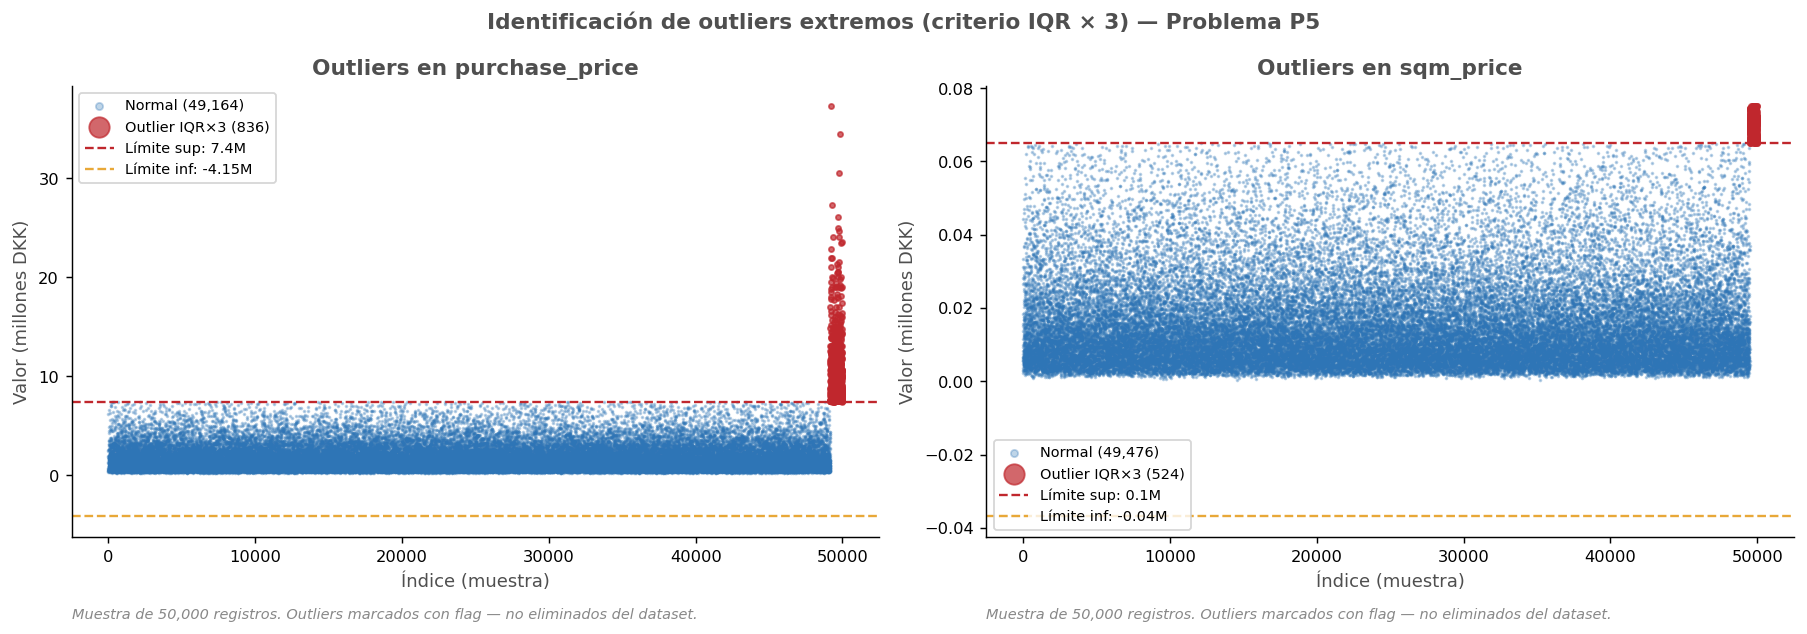

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Identificación de outliers extremos (criterio IQR × 3) — Problema P5',
             fontsize=12, fontweight='bold', color=GRIS)

for ax, col in zip(axes, ['purchase_price', 'sqm_price']):
    flag = f'{col}_outlier'
    if flag not in df.columns:
        continue
    muestra = df[[col, flag]].dropna().sample(min(50000, len(df)), random_state=42)
    norm = muestra[~muestra[flag]]
    out  = muestra[muestra[flag]]

    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 3 * IQR, Q3 + 3 * IQR

    ax.scatter(range(len(norm)), norm[col].values / 1e6,
               s=1, alpha=0.3, color=AZUL, label=f'Normal ({len(norm):,})')
    ax.scatter(range(len(norm), len(norm) + len(out)), out[col].values / 1e6,
               s=8, alpha=0.7, color=ROJO_UPC, label=f'Outlier IQR×3 ({len(out):,})')
    ax.axhline(upper / 1e6, color=ROJO_UPC, linestyle='--', linewidth=1.3,
               label=f'Límite sup: {upper/1e6:.1f}M')
    ax.axhline(lower / 1e6, color='#E8A838', linestyle='--', linewidth=1.3,
               label=f'Límite inf: {lower/1e6:.2f}M')
    ax.set_title(f'Outliers en {col}')
    ax.set_ylabel('Valor (millones DKK)')
    ax.set_xlabel('Índice (muestra)')
    ax.legend(markerscale=4, fontsize=8)
    save_note(ax, 'Muestra de 50,000 registros. Outliers marcados con flag — no eliminados del dataset.')

plt.tight_layout()
plt.show()

### 8.5 Precios por tipo de vivienda (house_type)

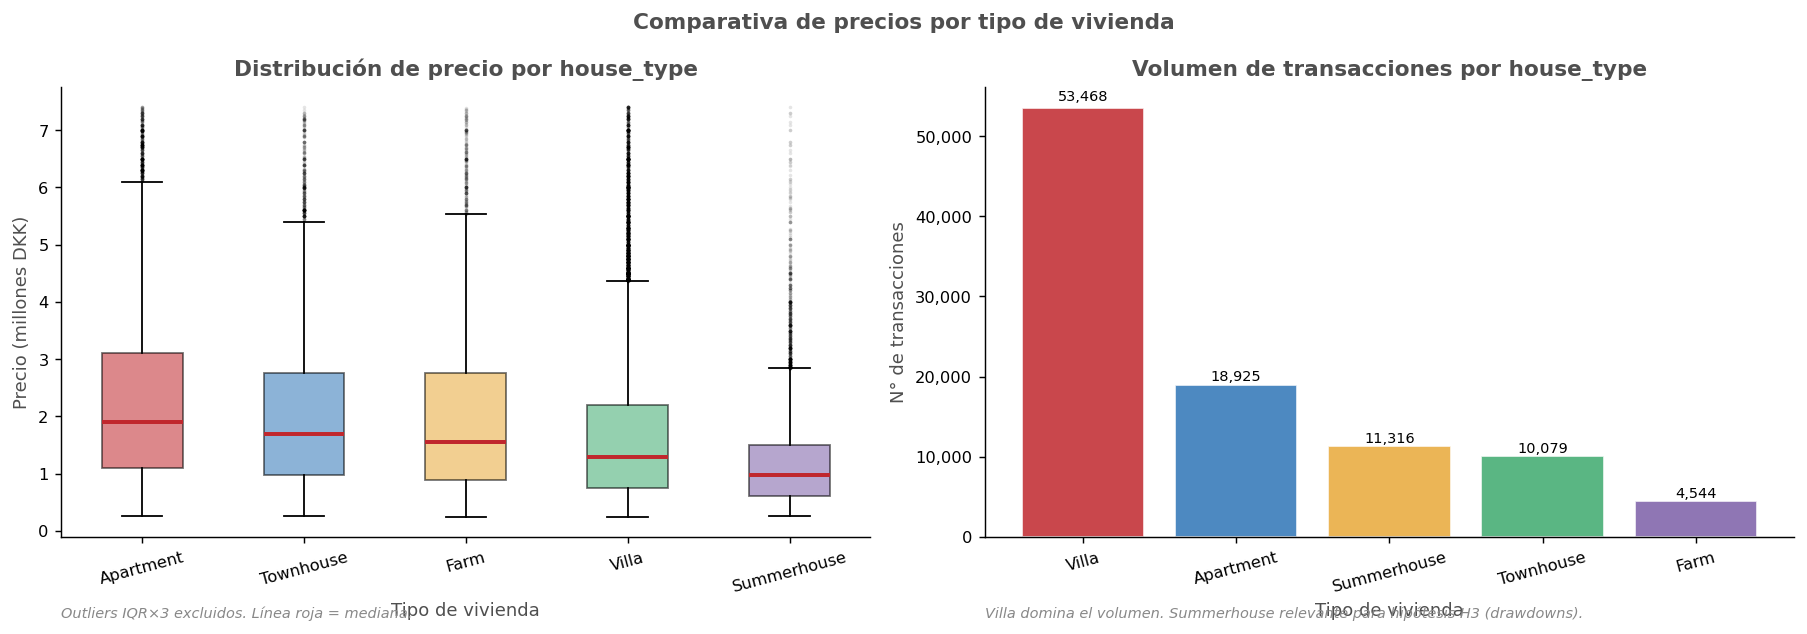

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparativa de precios por tipo de vivienda',
             fontsize=12, fontweight='bold', color=GRIS)

flag_col = 'purchase_price_outlier' if 'purchase_price_outlier' in df.columns else None
df_ht = df[~df[flag_col]].copy() if flag_col else df.copy()
df_ht = df_ht[df_ht['house_type'].notna()]
order_ht = df_ht.groupby('house_type')['purchase_price'].median().sort_values(ascending=False).index

# Boxplot
bp_data2 = [df_ht[df_ht['house_type'] == h]['purchase_price'].dropna().values / 1e6
            for h in order_ht]
bp2 = axes[0].boxplot(bp_data2, labels=order_ht, patch_artist=True,
                      medianprops=dict(color=ROJO_UPC, linewidth=2.2),
                      flierprops=dict(marker='.', alpha=0.1, markersize=2, color=GRIS))
for patch, color in zip(bp2['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.55)
axes[0].set_title('Distribución de precio por house_type')
axes[0].set_ylabel('Precio (millones DKK)')
axes[0].set_xlabel('Tipo de vivienda')
axes[0].tick_params(axis='x', rotation=15)
save_note(axes[0], 'Outliers IQR×3 excluidos. Línea roja = mediana.')

# Volumen por tipo
vol_ht = df_ht['house_type'].value_counts()
bars = axes[1].bar(vol_ht.index, vol_ht.values, color=PALETTE[:len(vol_ht)],
                   edgecolor='white', alpha=0.85)
axes[1].set_title('Volumen de transacciones por house_type')
axes[1].set_ylabel('N° de transacciones')
axes[1].set_xlabel('Tipo de vivienda')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=15)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                 f'{int(h):,}', ha='center', va='bottom', fontsize=8)
save_note(axes[1], 'Villa domina el volumen. Summerhouse relevante para hipótesis H3 (drawdowns).')

plt.tight_layout()
plt.show()

### 8.6 Distribución geográfica por región

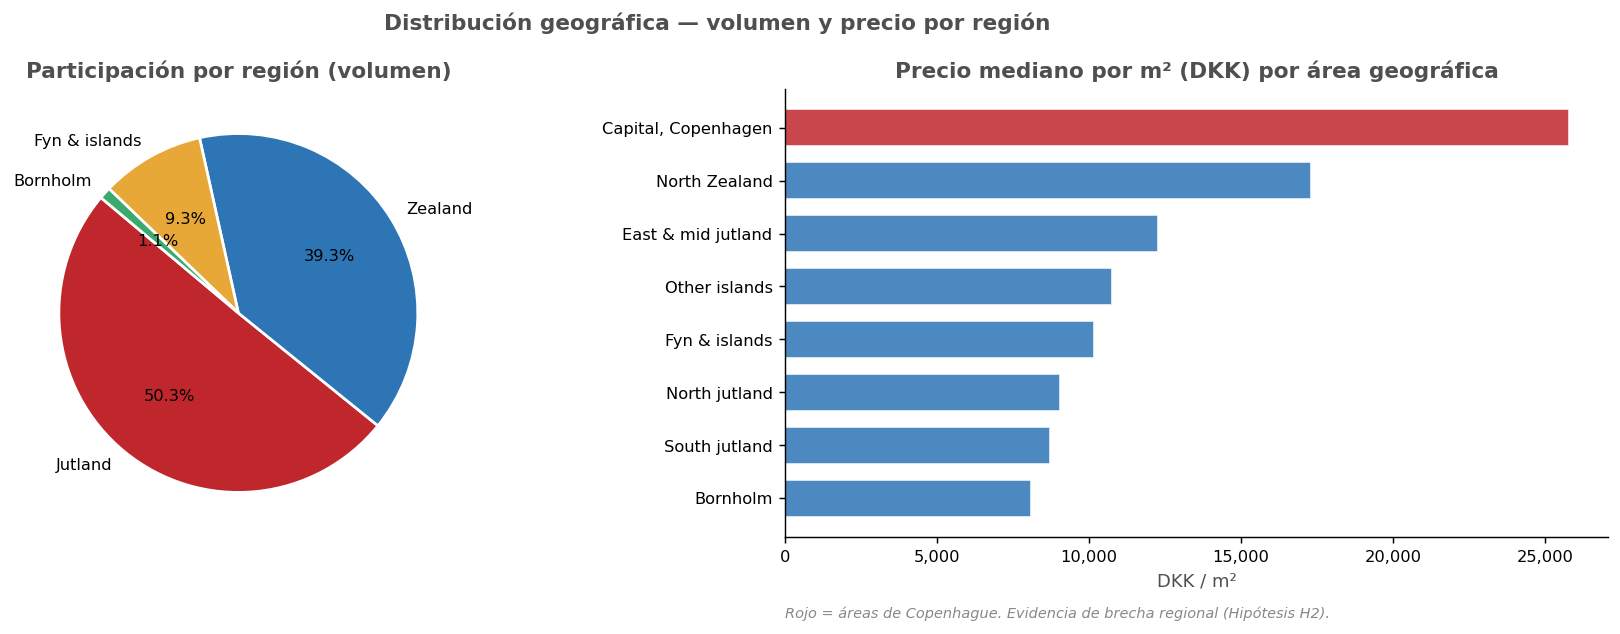

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución geográfica — volumen y precio por región',
             fontsize=12, fontweight='bold', color=GRIS)

flag_col = 'purchase_price_outlier' if 'purchase_price_outlier' in df.columns else None
df_geo = df[~df[flag_col]].copy() if flag_col else df.copy()

# Volumen por región
vol_reg = df_geo['region'].value_counts()
wedges, texts, autotexts = axes[0].pie(
    vol_reg.values,
    labels=vol_reg.index,
    autopct='%1.1f%%',
    colors=PALETTE[:len(vol_reg)],
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(9)
axes[0].set_title('Participación por región (volumen)')

# Precio mediano por área
precio_area = (df_geo.groupby('area')['sqm_price']
               .median()
               .sort_values(ascending=True))
colors_area = [ROJO_UPC if 'Copenhagen' in str(a) else AZUL for a in precio_area.index]
axes[1].barh(precio_area.index, precio_area.values,
             color=colors_area, edgecolor='white', alpha=0.85, height=0.7)
axes[1].set_title('Precio mediano por m² (DKK) por área geográfica')
axes[1].set_xlabel('DKK / m²')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
save_note(axes[1], 'Rojo = áreas de Copenhague. Evidencia de brecha regional (Hipótesis H2).')

plt.tight_layout()
plt.show()

### 8.7 Correlación entre variables numéricas

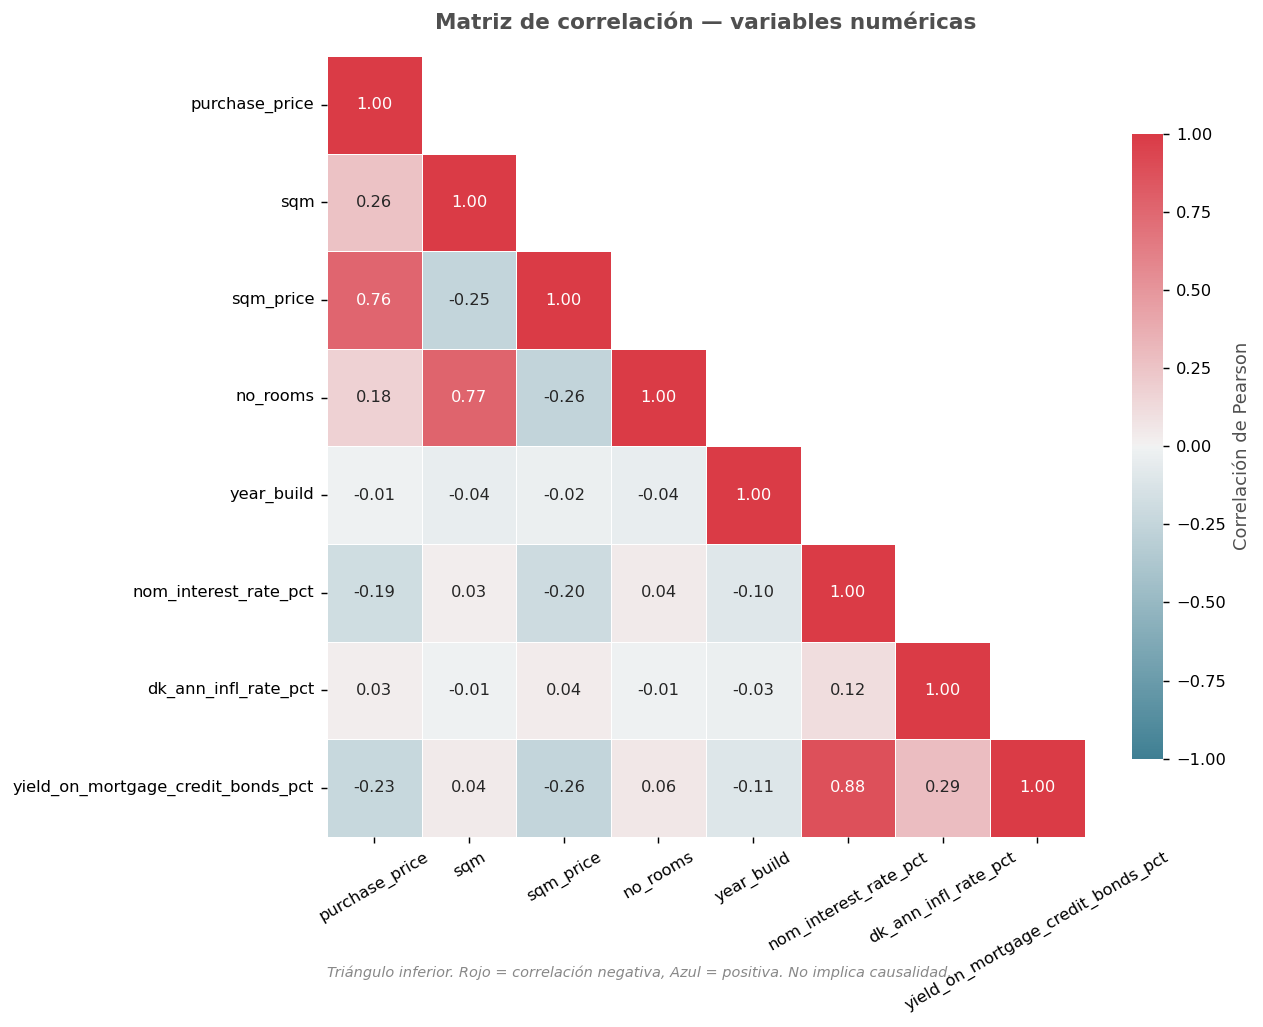

In [36]:
fig, ax = plt.subplots(figsize=(10, 8))

num_cols = [c for c in ['purchase_price', 'sqm', 'sqm_price', 'no_rooms', 'year_build',
                          'nom_interest_rate_pct', 'dk_ann_infl_rate_pct',
                          'yield_on_mortgage_credit_bonds_pct']
            if c in df.columns]

# Fallback para nombres originales si el renombrado no corrió aún
if not any('_pct' in c for c in df.columns):
    num_cols = [c for c in ['purchase_price', 'sqm', 'sqm_price', 'no_rooms', 'year_build'] if c in df.columns]

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'})

ax.set_title('Matriz de correlación — variables numéricas',
             fontsize=12, fontweight='bold', color=GRIS, pad=15)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
save_note(ax, 'Triángulo inferior. Rojo = correlación negativa, Azul = positiva. No implica causalidad.')

plt.tight_layout()
plt.show()

### 8.8 Variables macroeconómicas en el tiempo

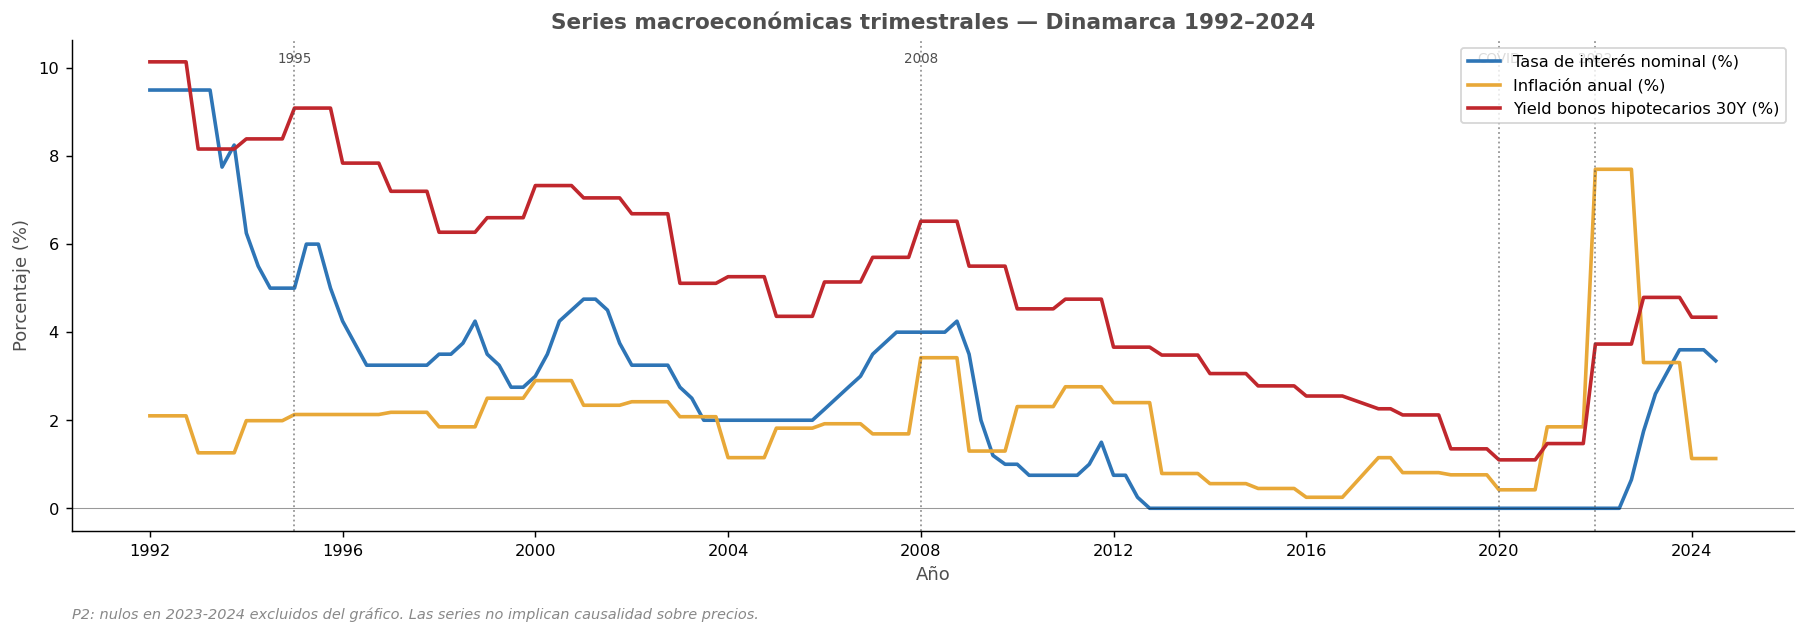

In [37]:
macro_map = {
    'nom_interest_rate_pct':                 ('Tasa de interés nominal (%)', AZUL),
    'dk_ann_infl_rate_pct':                  ('Inflación anual (%)', '#E8A838'),
    'yield_on_mortgage_credit_bonds_pct':    ('Yield bonos hipotecarios 30Y (%)', ROJO_UPC),
}
# Fallback nombres sin renombrar
if 'nom_interest_rate%25' in df.columns:
    macro_map = {
        'nom_interest_rate%25':                ('Tasa de interés nominal (%)', AZUL),
        'dk_ann_infl_rate%25':                 ('Inflación anual (%)', '#E8A838'),
        'yield_on_mortgage_credit_bonds%25':   ('Yield bonos hipotecarios 30Y (%)', ROJO_UPC),
    }

macro_cols_ok = [c for c in macro_map if c in df.columns]

if macro_cols_ok:
    macro_ts = (df[['date'] + macro_cols_ok]
                .dropna(subset=macro_cols_ok)
                .groupby(df['date'].dt.to_period('Q'))[macro_cols_ok]
                .mean()
                .reset_index())
    macro_ts['date'] = macro_ts['date'].dt.to_timestamp()

    fig, ax = plt.subplots(figsize=(14, 5))
    for col in macro_cols_ok:
        label, color = macro_map[col]
        ax.plot(macro_ts['date'], macro_ts[col], label=label,
                linewidth=2, color=color)

    for yr, label in {1995: '1995', 2008: '2008', 2020: 'COVID', 2022: '2022'}.items():
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color=GRIS,
                   linestyle=':', linewidth=1, alpha=0.6)
        ax.text(pd.Timestamp(f'{yr}-01-01'), ax.get_ylim()[1] * 0.95,
                label, fontsize=7.5, color=GRIS, ha='center')

    ax.set_title('Series macroeconómicas trimestrales — Dinamarca 1992–2024')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xlabel('Año')
    ax.legend(loc='upper right')
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
    save_note(ax, 'P2: nulos en 2023-2024 excluidos del gráfico. Las series no implican causalidad sobre precios.')

    plt.tight_layout()
    plt.show()
else:
    print('⚠ Columnas macro no encontradas — ejecutar celda P8 de renombrado primero.')